# PayShield — Fraud Detection: Exploratory Data Analysis

---
## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing and feature importance
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42

In [2]:
# Relative path so the notebook runs on any machine
df = pd.read_csv("C:/Users/Merin Manickal Roy/Downloads/processed_dataset.csv")
df

,hour,hour_label,day_of_week,day_name,month,month_name,age,city_pop,distance,log_amt,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0,12:00 AM,2,Tuesday,1,January,40,149,0.2723,4.6843,...,True,False,False,False,False,False,False,False,False,False
1,0,12:00 AM,2,Tuesday,1,January,56,4154,0.9758,5.3987,...,False,False,False,False,False,False,False,False,False,False
2,0,12:07 AM,2,Tuesday,1,January,73,589,0.2989,4.5777,...,True,False,False,False,False,False,False,False,False,False
3,0,12:09 AM,2,Tuesday,1,January,51,899,0.7054,2.1713,...,False,False,False,False,False,False,False,False,True,False
4,0,12:21 AM,2,Tuesday,1,January,51,471,0.8507,2.0605,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339602,23,11:57 PM,4,Thursday,12,December,81,145,0.9949,2.6159,...,False,False,True,False,False,False,False,False,False,False
339603,23,11:58 PM,4,Thursday,12,December,62,308,0.7532,2.6405,...,False,False,False,True,False,False,False,False,False,False
339604,23,11:59 PM,4,Thursday,12,December,54,519,0.7808,3.8015,...,False,True,False,False,False,False,False,False,False,False
339605,23,11:59 PM,4,Thursday,12,December,39,3684,0.9353,4.4760,...,False,False,False,True,False,False,False,False,False,False


---
## 2. Data overview and quality checks

In [3]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (339607, 24)


,hour,hour_label,day_of_week,day_name,month,month_name,age,city_pop,distance,log_amt,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0,12:00 AM,2,Tuesday,1,January,40,149,0.2723,4.6843,...,True,False,False,False,False,False,False,False,False,False
1,0,12:00 AM,2,Tuesday,1,January,56,4154,0.9758,5.3987,...,False,False,False,False,False,False,False,False,False,False
2,0,12:07 AM,2,Tuesday,1,January,73,589,0.2989,4.5777,...,True,False,False,False,False,False,False,False,False,False
3,0,12:09 AM,2,Tuesday,1,January,51,899,0.7054,2.1713,...,False,False,False,False,False,False,False,False,True,False
4,0,12:21 AM,2,Tuesday,1,January,51,471,0.8507,2.0605,...,False,False,False,False,False,True,False,False,False,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     339607 non-null  int64  
 1   hour_label               339607 non-null  str    
 2   day_of_week              339607 non-null  int64  
 3   day_name                 339607 non-null  str    
 4   month                    339607 non-null  int64  
 5   month_name               339607 non-null  str    
 6   age                      339607 non-null  int64  
 7   city_pop                 339607 non-null  int64  
 8   distance                 339607 non-null  float64
 9   log_amt                  339607 non-null  float64
 10  is_fraud                 339607 non-null  int64  
 11  category_food_dining     339607 non-null  bool   
 12  category_gas_transport   339607 non-null  bool   
 13  category_grocery_net     339607 non-null  bool   
 14  category_grocer

In [5]:
df.columns.tolist()

['hour',
 'hour_label',
 'day_of_week',
 'day_name',
 'month',
 'month_name',
 'age',
 'city_pop',
 'distance',
 'log_amt',
 'is_fraud',
 'category_food_dining',
 'category_gas_transport',
 'category_grocery_net',
 'category_grocery_pos',
 'category_health_fitness',
 'category_home',
 'category_kids_pets',
 'category_misc_net',
 'category_misc_pos',
 'category_personal_care',
 'category_shopping_net',
 'category_shopping_pos',
 'category_travel']

In [6]:
df.isnull().sum()

hour                       0
hour_label                 0
day_of_week                0
day_name                   0
month                      0
month_name                 0
age                        0
city_pop                   0
distance                   0
log_amt                    0
is_fraud                   0
category_food_dining       0
category_gas_transport     0
category_grocery_net       0
category_grocery_pos       0
category_health_fitness    0
category_home              0
category_kids_pets         0
category_misc_net          0
category_misc_pos          0
category_personal_care     0
category_shopping_net      0
category_shopping_pos      0
category_travel            0
dtype: int64

In [7]:
# Descriptive statistics for continuous features
df[['age', 'city_pop', 'distance', 'log_amt']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"339,607.0000",47.3298,17.0339,17.0000,34.0000,45.0000,58.0000,93.0000
city_pop,"339,607.0000","107,140.8655","293,029.8873",46.0000,471.0000,"1,645.0000","35,439.0000","2,383,912.0000"
distance,"339,607.0000",0.7652,0.2850,0.0023,0.5643,0.7978,0.9772,1.4122
log_amt,"339,607.0000",3.5259,1.2922,0.6931,2.3609,3.8599,4.4350,7.3704


In [8]:
# Data quality checks
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Constant columns:", [c for c in df.columns if df[c].nunique() == 1])

Duplicate rows: 0
Missing values: 0
Constant columns: []


---
## 3. Class distribution and its modelling impact

In [9]:
df['is_fraud'].value_counts()

is_fraud
0    337825
1      1782
Name: count, dtype: int64

In [10]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0   99.4753
1    0.5247
Name: proportion, dtype: float64

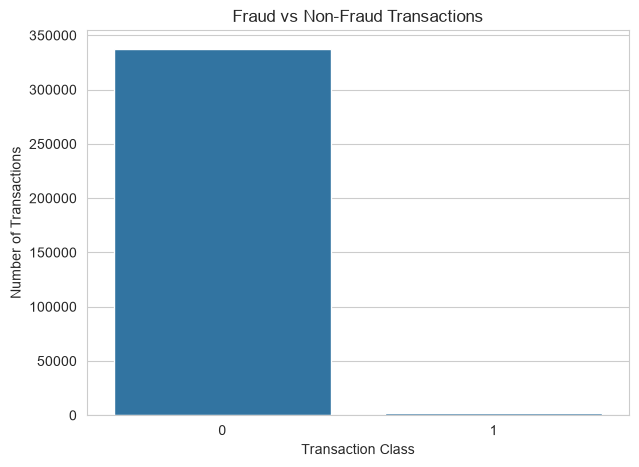

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

---
## 4. Univariate distributions and skewness

In [15]:
numeric_cols = [
    'age',
    'city_pop',
    'distance',
    'log_amt'
]

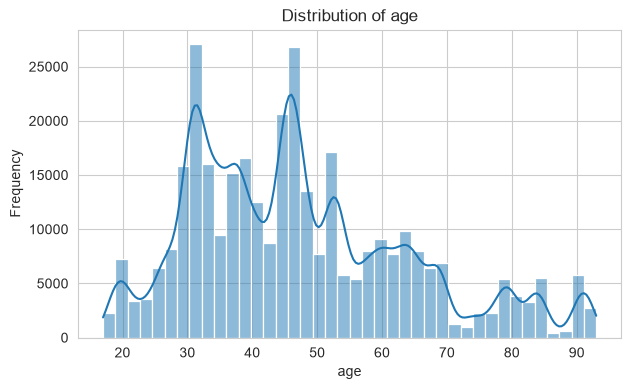

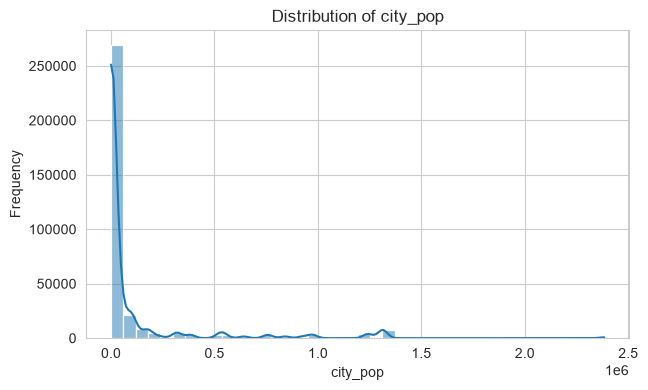

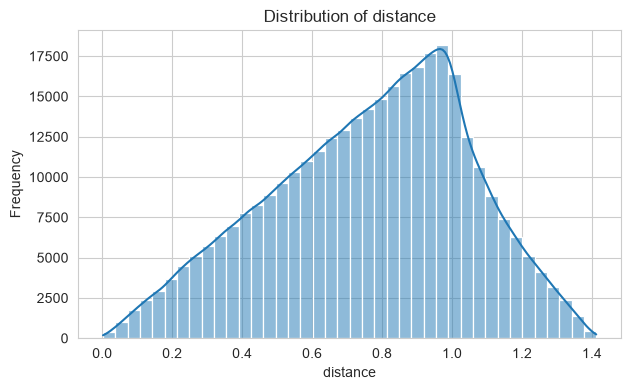

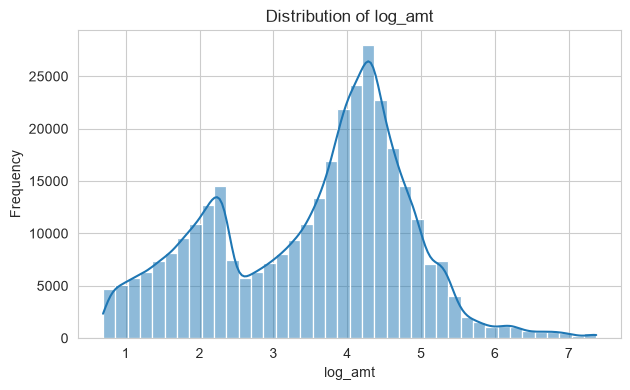

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [17]:
for col in numeric_cols:
    print(col, "Skewness =", round(df[col].skew(), 3))

age Skewness = 0.698
city_pop Skewness = 3.682
distance Skewness = -0.307
log_amt Skewness = -0.29


---
## 5. Bivariate analysis by fraud status

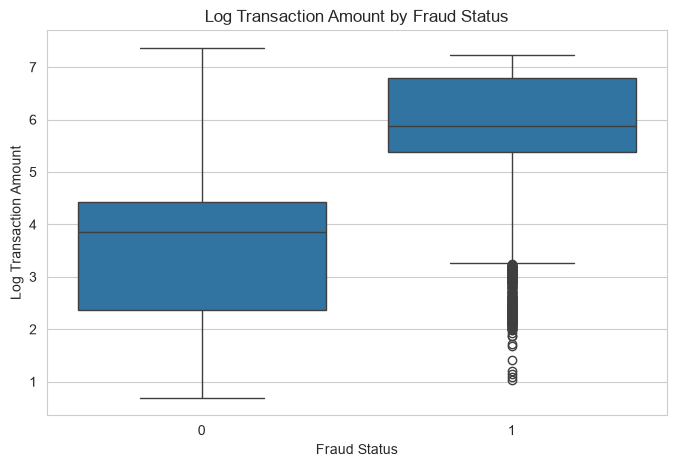

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='log_amt',
    data=df
)

plt.title("Log Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Log Transaction Amount")

plt.show()

In [19]:
df.groupby('is_fraud')['log_amt'].agg(['mean', 'median'])

,mean,median
is_fraud,,
0,3.5153,3.8555
1,5.5339,5.8789


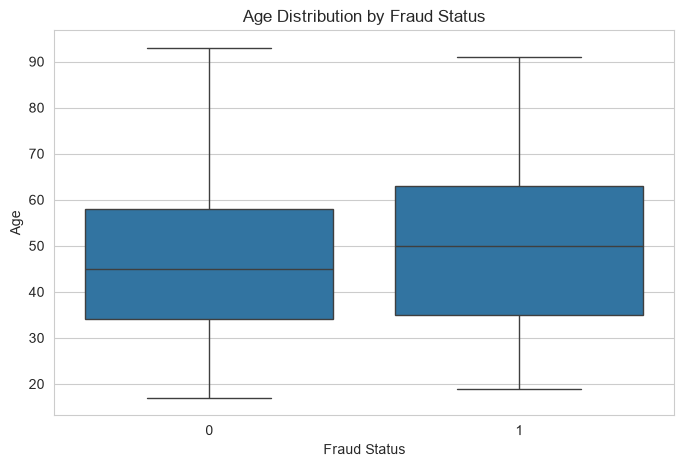

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='age',
    data=df
)

plt.title("Age Distribution by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Age")

plt.show()

In [21]:
df.groupby('is_fraud')['age'].agg(['mean', 'median'])

,mean,median
is_fraud,,
0,47.3143,45.0000
1,50.2705,50.0000


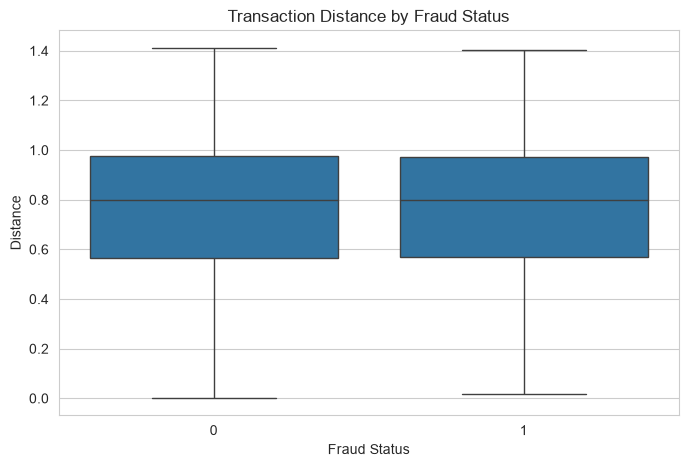

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='distance',
    data=df
)

plt.title("Transaction Distance by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Distance")

plt.show()

---
## 6. Temporal patterns

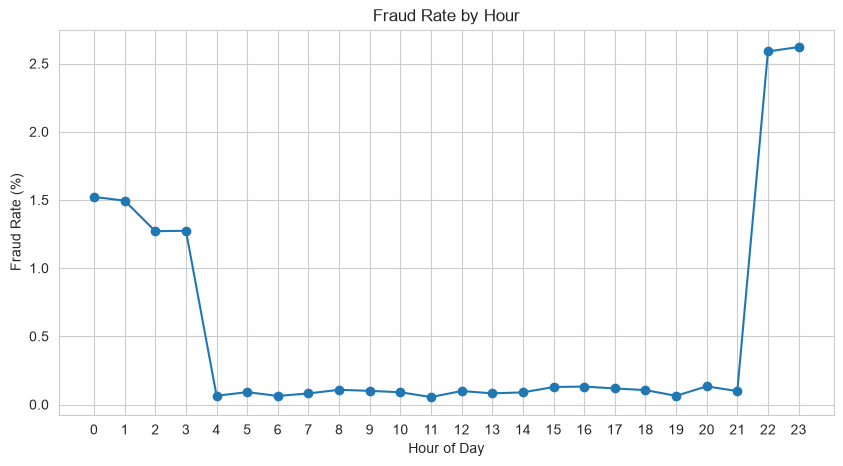

In [23]:
hour_fraud = df.groupby('hour')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))

hour_fraud.plot(marker='o')

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(range(24))

plt.show()

In [24]:
df['late_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3])

In [25]:
df.groupby('late_night')['is_fraud'].mean() * 100

late_night
False   0.0969
True    1.9245
Name: is_fraud, dtype: float64

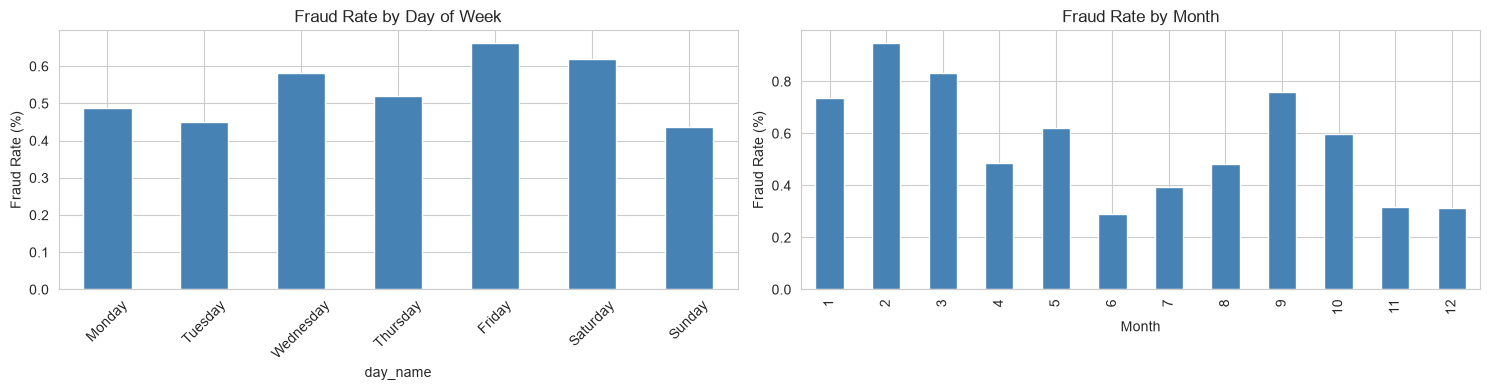

Day-of-week spread : 0.437% to 0.663%
Month spread       : 0.289% to 0.949%


In [26]:
# Fraud rate by day of week and month
fig, axes = plt.subplots(1, 2, figsize=(15,4))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_fraud = (df.groupby('day_name')['is_fraud'].mean() * 100).reindex(day_order)
day_fraud.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Fraud Rate by Day of Week")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis='x', rotation=45)

month_fraud = (df.groupby('month')['is_fraud'].mean() * 100)
month_fraud.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Fraud Rate by Month")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

print("Day-of-week spread : %.3f%% to %.3f%%" % (day_fraud.min(), day_fraud.max()))
print("Month spread       : %.3f%% to %.3f%%" % (month_fraud.min(), month_fraud.max()))

---
## 7. Category-level fraud rates

In [27]:
category_cols = [
    col for col in df.columns
    if col.startswith('category_')
]

category_fraud_rate = {}

for col in category_cols:
    category_fraud_rate[col] = df.loc[df[col], 'is_fraud'].mean() * 100

category_fraud_rate = pd.Series(category_fraud_rate).sort_values(
    ascending=False
)

category_fraud_rate

category_shopping_net     1.4443
category_grocery_pos      1.3229
category_misc_net         1.2842
category_shopping_pos     0.6166
category_gas_transport    0.4360
category_travel           0.3197
category_misc_pos         0.3096
category_grocery_net      0.2378
category_personal_care    0.2254
category_kids_pets        0.1852
category_food_dining      0.1649
category_health_fitness   0.1593
category_home             0.1538
dtype: float64

In [28]:
# Fraud rate AND absolute fraud count per category, so volume context is visible
cat_summary = pd.DataFrame({
    'Transactions': [df[c].sum() for c in category_cols],
    'Fraud_Count': [df.loc[df[c], 'is_fraud'].sum() for c in category_cols],
    'Fraud_Rate_%': [df.loc[df[c], 'is_fraud'].mean() * 100 for c in category_cols]
}, index=[c.replace('category_', '') for c in category_cols])

cat_summary['Lift_vs_Base'] = cat_summary['Fraud_Rate_%'] / (df['is_fraud'].mean() * 100)
cat_summary.sort_values('Fraud_Rate_%', ascending=False)

,Transactions,Fraud_Count,Fraud_Rate_%,Lift_vs_Base
shopping_net,26379,381,1.4443,2.7526
grocery_pos,32732,433,1.3229,2.5211
misc_net,16898,217,1.2842,2.4473
shopping_pos,30329,187,0.6166,1.1750
gas_transport,35089,153,0.4360,0.8310
travel,10322,33,0.3197,0.6093
misc_pos,20024,62,0.3096,0.5901
grocery_net,11355,27,0.2378,0.4532
personal_care,24406,55,0.2254,0.4295
kids_pets,29704,55,0.1852,0.3529


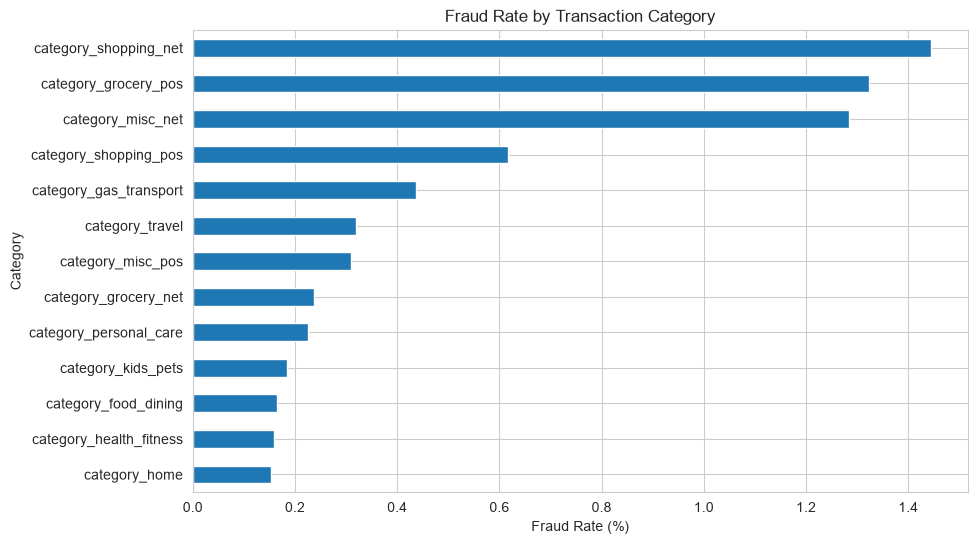

In [29]:
plt.figure(figsize=(10,6))

category_fraud_rate.sort_values().plot(kind='barh')

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Category")

plt.show()

## 8. Correlation analysis and feature importance

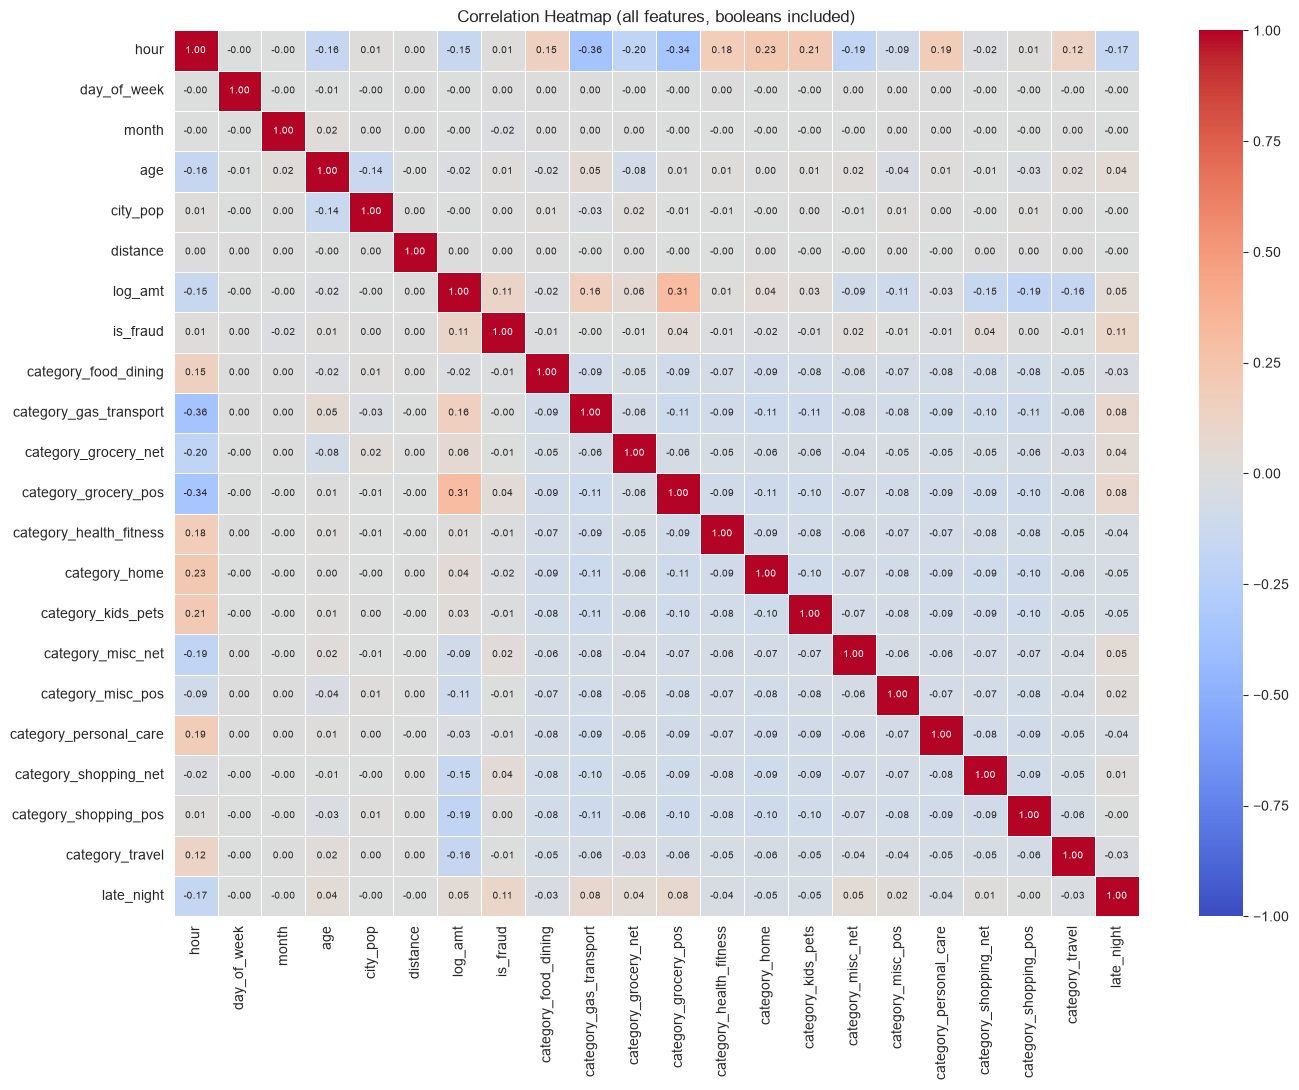

In [30]:
# Cast booleans to int so category flags are included in the correlation matrix
corr_df = df.drop(columns=['hour_label', 'day_name', 'month_name']).astype(
    {c: int for c in category_cols + ['late_night']}
)

correlation = corr_df.corr()

plt.figure(figsize=(14,11))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1, center=0,   # symmetric scale so sign and strength are readable
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap (all features, booleans included)")
plt.tight_layout()
plt.show()

In [31]:
# Point-biserial correlation of every feature with the target
fraud_corr = correlation['is_fraud'].drop('is_fraud')
fraud_corr_ranked = fraud_corr.reindex(fraud_corr.abs().sort_values(ascending=False).index)

print("Correlation with is_fraud (ranked by absolute strength):")
print(fraud_corr_ranked.head(12).to_string())

Correlation with is_fraud (ranked by absolute strength):
log_amt                    0.1129
late_night                 0.1071
category_shopping_net      0.0369
category_grocery_pos       0.0361
category_misc_net          0.0241
month                     -0.0178
category_home             -0.0167
category_kids_pets        -0.0146
category_health_fitness   -0.0135
category_food_dining      -0.0134
age                        0.0125
hour                       0.0124


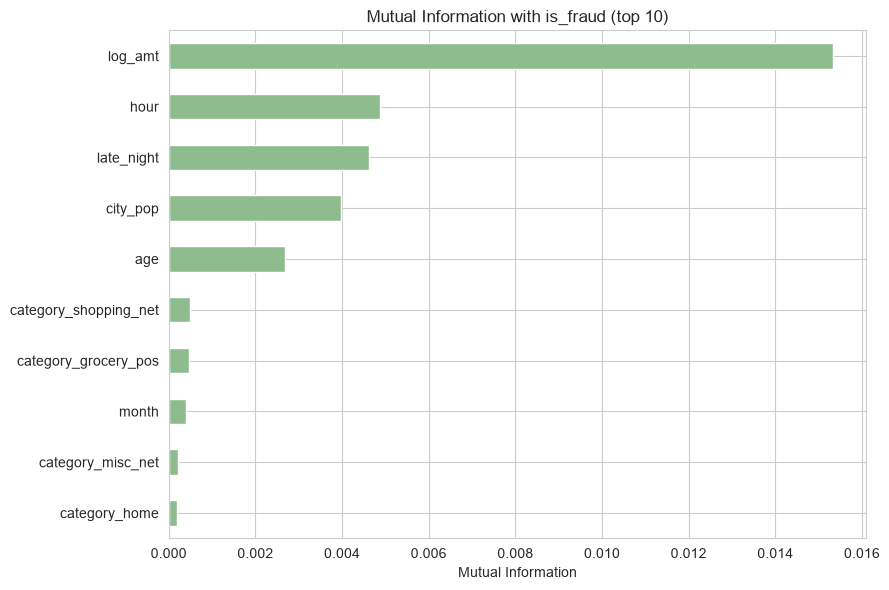

log_amt                 0.0153
hour                    0.0049
late_night              0.0046
city_pop                0.0040
age                     0.0027
category_shopping_net   0.0005
category_grocery_pos    0.0005
month                   0.0004
category_misc_net       0.0002
category_home           0.0002
dtype: float64

In [32]:
# Mutual information captures non-linear relationships that correlation misses
features = ['hour', 'day_of_week', 'month', 'age', 'city_pop',
            'distance', 'log_amt', 'late_night'] + category_cols

X = df[features].astype(float)
y = df['is_fraud']

discrete_mask = [f in (['hour', 'day_of_week', 'month', 'late_night'] + category_cols)
                 for f in features]

mi = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=features).sort_values(ascending=False)

plt.figure(figsize=(9,6))
mi_scores.head(10).sort_values().plot(kind='barh', color='darkseagreen')
plt.title("Mutual Information with is_fraud (top 10)")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

mi_scores.head(10)

## 9. Statistical significance testing

In [33]:
# Mann-Whitney U tests for continuous features
results = []
for col in ['log_amt', 'age', 'distance', 'city_pop']:
    fraud_vals = df.loc[df['is_fraud'] == 1, col]
    legit_vals = df.loc[df['is_fraud'] == 0, col]

    u_stat, p_val = stats.mannwhitneyu(fraud_vals, legit_vals, alternative='two-sided')

    # Rank-biserial correlation = effect size (0 = none, 1 = complete separation)
    effect = (2 * u_stat) / (len(fraud_vals) * len(legit_vals)) - 1

    results.append({
        'Feature': col,
        'Median_Fraud': fraud_vals.median(),
        'Median_Legit': legit_vals.median(),
        'p_value': p_val,
        'Effect_Size': effect,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

mwu = pd.DataFrame(results)
mwu['p_value'] = mwu['p_value'].apply(lambda x: f"{x:.2e}")
mwu

,Feature,Median_Fraud,Median_Legit,p_value,Effect_Size,Significant
0,log_amt,5.8789,3.8555,0.00e+00,0.6608,Yes
1,age,50.0000,45.0000,2.38e-13,0.1004,Yes
2,distance,0.7978,0.7978,9.65e-01,-0.0006,No
3,city_pop,"1,645.0000","1,645.0000",8.69e-01,0.0023,No


In [34]:
# Chi-square tests: late_night and each transaction category vs is_fraud
chi_results = []

for col in ['late_night'] + category_cols:
    contingency = pd.crosstab(df[col], df['is_fraud'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    cramers_v = np.sqrt(chi2 / len(df))   # 2x2 table -> V = sqrt(chi2/n)
    rate_in = df.loc[df[col] == True, 'is_fraud'].mean() * 100
    rate_out = df.loc[df[col] == False, 'is_fraud'].mean() * 100

    chi_results.append({
        'Feature': col.replace('category_', ''),
        'Rate_When_True_%': rate_in,
        'Rate_When_False_%': rate_out,
        'Lift': rate_in / rate_out,
        'Chi2': chi2,
        'p_value': p_val,
        'Cramers_V': cramers_v
    })

chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
chi_df['p_value'] = chi_df['p_value'].apply(lambda x: f"{x:.2e}")
chi_df

,Feature,Rate_When_True_%,Rate_When_False_%,Lift,Chi2,p_value,Cramers_V
0,late_night,1.9245,0.0969,19.8638,"3,892.9061",0.00e+00,0.1071
11,shopping_net,1.4443,0.4473,3.2292,461.4665,2.31e-102,0.0369
4,grocery_pos,1.3229,0.4396,3.0093,440.3885,8.91e-98,0.0360
8,misc_net,1.2842,0.4850,2.6480,194.9683,2.62e-44,0.0240
6,home,0.1538,0.5640,0.2726,94.0139,3.13e-22,0.0166
7,kids_pets,0.1852,0.5573,0.3323,71.1945,3.24e-17,0.0145
5,health_fitness,0.1593,0.5508,0.2893,61.1568,5.27e-15,0.0134
1,food_dining,0.1649,0.5509,0.2994,60.5513,7.17e-15,0.0134
10,personal_care,0.2254,0.5479,0.4113,44.5339,2.50e-11,0.0115
9,misc_pos,0.3096,0.5382,0.5753,18.4255,1.77e-05,0.0074


## 10. Feature interaction analysis

In [35]:
category_cols = [
    col for col in df.columns
    if col.startswith('category_')
]

interaction_results = []

for col in category_cols:

    subset = df[
        (df[col] == True) &
        (df['late_night'] == True)
    ]

    if len(subset) > 0:
        interaction_results.append({
            'Category': col,
            'Transactions': len(subset),
            'Fraud_Count': subset['is_fraud'].sum(),
            'Fraud_Rate': subset['is_fraud'].mean() * 100
        })

interaction_df = pd.DataFrame(interaction_results)

interaction_df.sort_values(
    'Fraud_Rate',
    ascending=False
)

,Category,Transactions,Fraud_Count,Fraud_Rate
10,category_shopping_net,6621,325,4.9086
7,category_misc_net,5404,186,3.4419
3,category_grocery_pos,11051,377,3.4115
11,category_shopping_pos,6976,148,2.1216
12,category_travel,1758,26,1.4790
9,category_personal_care,4103,48,1.1699
1,category_gas_transport,11679,136,1.1645
8,category_misc_pos,5267,55,1.0442
6,category_kids_pets,4882,44,0.9013
5,category_home,5431,46,0.8470


In [36]:
# Does category x late_night beat the sum of its parts?
interaction_df = interaction_df.copy()
interaction_df['Clean_Category'] = interaction_df['Category'].str.replace('category_', '')

base_rate = df['is_fraud'].mean() * 100
late_rate = df.loc[df['late_night'], 'is_fraud'].mean() * 100

comparison = []
for _, row in interaction_df.iterrows():
    col = row['Category']
    cat_only = df.loc[df[col], 'is_fraud'].mean() * 100
    comparison.append({
        'Category': row['Clean_Category'],
        'Category_Alone_%': cat_only,
        'LateNight_Alone_%': late_rate,
        'Combined_%': row['Fraud_Rate'],
        'Combined_vs_Category': row['Fraud_Rate'] / cat_only,
        'Combined_vs_Base': row['Fraud_Rate'] / base_rate
    })

comp_df = pd.DataFrame(comparison).sort_values('Combined_%', ascending=False)
print(f"Overall base rate: {base_rate:.3f}%   |   Late-night alone: {late_rate:.3f}%\n")
comp_df

Overall base rate: 0.525%   |   Late-night alone: 1.924%



,Category,Category_Alone_%,LateNight_Alone_%,Combined_%,Combined_vs_Category,Combined_vs_Base
10,shopping_net,1.4443,1.9245,4.9086,3.3985,9.3547
7,misc_net,1.2842,1.9245,3.4419,2.6802,6.5594
3,grocery_pos,1.3229,1.9245,3.4115,2.5788,6.5014
11,shopping_pos,0.6166,1.9245,2.1216,3.4409,4.0432
12,travel,0.3197,1.9245,1.4790,4.6260,2.8185
9,personal_care,0.2254,1.9245,1.1699,5.1913,2.2295
1,gas_transport,0.4360,1.9245,1.1645,2.6706,2.2192
8,misc_pos,0.3096,1.9245,1.0442,3.3726,1.9901
6,kids_pets,0.1852,1.9245,0.9013,4.8675,1.7176
5,home,0.1538,1.9245,0.8470,5.5081,1.6142


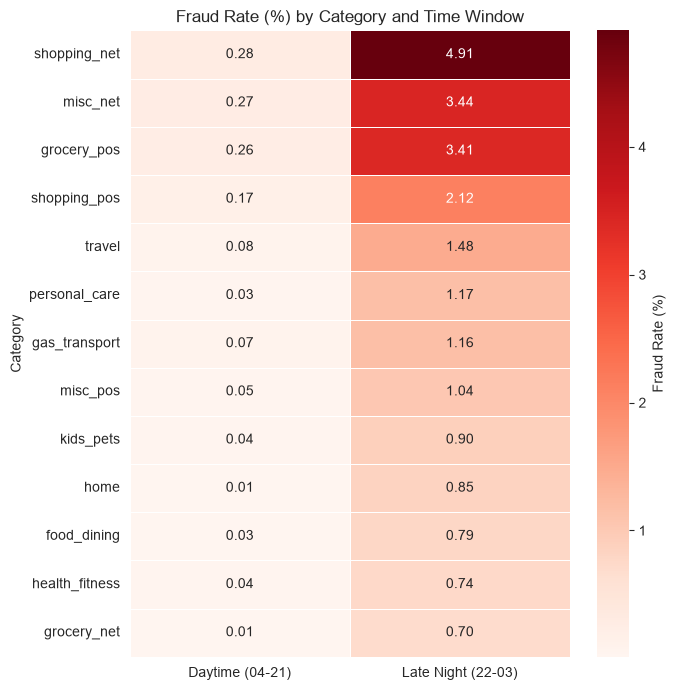

In [37]:
# Heatmap: fraud rate by category x time window
heat_rows = []
for col in category_cols:
    heat_rows.append({
        'Category': col.replace('category_', ''),
        'Daytime (04-21)': df.loc[df[col] & ~df['late_night'], 'is_fraud'].mean() * 100,
        'Late Night (22-03)': df.loc[df[col] & df['late_night'], 'is_fraud'].mean() * 100
    })

heat = pd.DataFrame(heat_rows).set_index('Category').sort_values('Late Night (22-03)', ascending=False)

plt.figure(figsize=(7,7))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Fraud Rate (%)'})
plt.title("Fraud Rate (%) by Category and Time Window")
plt.tight_layout()
plt.show()

In [38]:
# Business value of the interaction: how much fraud does a narrow rule capture?
high_risk_cats = ['category_shopping_net', 'category_grocery_pos', 'category_misc_net']
rule = df['late_night'] & df[high_risk_cats].any(axis=1)

print("RULE: late night (22:00-03:00) AND category in {shopping_net, grocery_pos, misc_net}\n")
print(f"Transactions flagged : {rule.sum():,}  ({100*rule.mean():.2f}% of all volume)")
print(f"Frauds captured      : {df.loc[rule, 'is_fraud'].sum():,}  "
      f"({100*df.loc[rule, 'is_fraud'].sum()/df['is_fraud'].sum():.1f}% of all fraud)")
print(f"Fraud rate in segment: {df.loc[rule, 'is_fraud'].mean()*100:.2f}%  "
      f"({df.loc[rule, 'is_fraud'].mean()/df['is_fraud'].mean():.1f}x base rate)")

RULE: late night (22:00-03:00) AND category in {shopping_net, grocery_pos, misc_net}

Transactions flagged : 23,076  (6.79% of all volume)
Frauds captured      : 888  (49.8% of all fraud)
Fraud rate in segment: 3.85%  (7.3x base rate)


## 11. Anomaly and data-integrity findings

In [39]:
# Anomaly 1 — the `distance` feature looks synthetic
print("ANOMALY 1: distance feature")
print(f"  Range          : {df['distance'].min():.6f} to {df['distance'].max():.6f}")
print(f"  Upper bound    : sqrt(2) = {np.sqrt(2):.6f}  <-- max is ~99.9% of this")
print(f"  Unique values  : {df['distance'].nunique():,} out of {len(df):,} rows (all distinct)")
print(f"  Skewness       : {df['distance'].skew():.3f} (near-symmetric triangular)")
print(f"  Corr w/ fraud  : {df['distance'].corr(df['is_fraud']):.6f}")
print(f"  Mann-Whitney p : 0.965 (not significant)")

ANOMALY 1: distance feature
  Range          : 0.002277 to 1.412221
  Upper bound    : sqrt(2) = 1.414214  <-- max is ~99.9% of this
  Unique values  : 339,607 out of 339,607 rows (all distinct)
  Skewness       : -0.307 (near-symmetric triangular)
  Corr w/ fraud  : 0.000257
  Mann-Whitney p : 0.965 (not significant)


ANOMALY 2: hourly fraud rate discontinuity

Hour 03 -> 04 :  1.274%  ->  0.064%   (20x drop in one hour)
Hour 21 -> 22 :  0.098%  ->  2.589%   (26x jump in one hour)

Daytime window (04-21) spread : 0.054% to 0.133%  -- remarkably flat


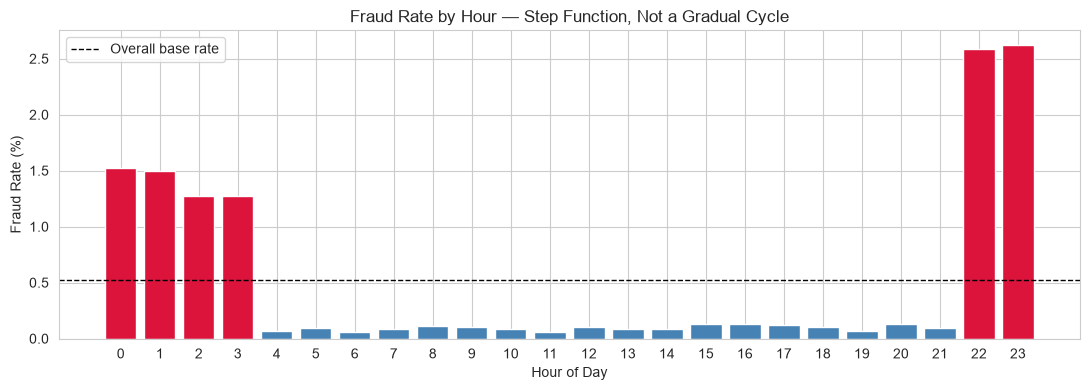

In [40]:
# Anomaly 2 — the hourly fraud rate is a step function, not a cycle
hourly = df.groupby('hour')['is_fraud'].mean() * 100

print("ANOMALY 2: hourly fraud rate discontinuity\n")
print("Hour 03 -> 04 :  %.3f%%  ->  %.3f%%   (%.0fx drop in one hour)"
      % (hourly[3], hourly[4], hourly[3]/hourly[4]))
print("Hour 21 -> 22 :  %.3f%%  ->  %.3f%%   (%.0fx jump in one hour)"
      % (hourly[21], hourly[22], hourly[22]/hourly[21]))
print()
print("Daytime window (04-21) spread : %.3f%% to %.3f%%  -- remarkably flat"
      % (hourly[4:22].min(), hourly[4:22].max()))

plt.figure(figsize=(11,4))
colors = ['crimson' if h in [22,23,0,1,2,3] else 'steelblue' for h in hourly.index]
plt.bar(hourly.index, hourly.values, color=colors)
plt.axhline(df['is_fraud'].mean()*100, ls='--', c='black', lw=1, label='Overall base rate')
plt.title("Fraud Rate by Hour — Step Function, Not a Gradual Cycle")
plt.xlabel("Hour of Day"); plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24)); plt.legend(); plt.tight_layout()
plt.show()

In [41]:
# Anomaly 3 — city_pop outlier load
q1, q3 = df['city_pop'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = ((df['city_pop'] > q3 + 1.5*iqr) | (df['city_pop'] < q1 - 1.5*iqr)).sum()

print("ANOMALY 3: city_pop distribution")
print(f"  Median          : {df['city_pop'].median():,.0f}")
print(f"  Max             : {df['city_pop'].max():,.0f}")
print(f"  IQR outliers    : {outliers:,} rows ({100*outliers/len(df):.1f}% of the dataset)")
print(f"  Skewness        : {df['city_pop'].skew():.3f}")
print("  -> These are legitimate large cities, NOT errors. Do not remove them; log-transform.")

ANOMALY 3: city_pop distribution
  Median          : 1,645
  Max             : 2,383,912
  IQR outliers    : 65,168 rows (19.2% of the dataset)
  Skewness        : 3.682
  -> These are legitimate large cities, NOT errors. Do not remove them; log-transform.


---
## 12. Key findings and actionable recommendations

In [40]:
print("="*72)
print("PAYSHIELD EDA — SUMMARY")
print("="*72)
print(f"Transactions analysed : {len(df):,}")
print(f"Fraudulent            : {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.3f}%)")
print(f"Class ratio           : 1 : {(df['is_fraud']==0).sum()/df['is_fraud'].sum():.0f}")
print(f"Data quality          : 0 missing, 0 duplicates")
print("-"*72)
print("STRONGEST SIGNALS")
print(f"  1. log_amt       corr 0.113 | effect size 0.661 | median 5.88 vs 3.86")
print(f"  2. late_night    corr 0.107 | 1.92% vs 0.097%   | ~20x lift")
print(f"  3. category      shopping_net / grocery_pos / misc_net at 2.6-3.2x lift")
print("-"*72)
print("NO SIGNAL (recommend dropping)")
print(f"  distance  (p=0.965)   city_pop (p=0.869)   day_of_week   month")
print("="*72)

PAYSHIELD EDA — SUMMARY
Transactions analysed : 339,607
Fraudulent            : 1,782 (0.525%)
Class ratio           : 1 : 190
Data quality          : 0 missing, 0 duplicates
------------------------------------------------------------------------
STRONGEST SIGNALS
  1. log_amt       corr 0.113 | effect size 0.661 | median 5.88 vs 3.86
  2. late_night    corr 0.107 | 1.92% vs 0.097%   | ~20x lift
  3. category      shopping_net / grocery_pos / misc_net at 2.6-3.2x lift
------------------------------------------------------------------------
NO SIGNAL (recommend dropping)
  distance  (p=0.965)   city_pop (p=0.869)   day_of_week   month


### Top 3 actionable insights

---

1. Late-night online transactions are much more risky.
Fraud is about 9.4× higher for shopping_net transactions between 10 PM–3 AM compared to the overall fraud rate. This suggests that adding OTP/3-D Secure verification during this time could help reduce fraud.

2. Transaction amount is a strong fraud indicator.
Fraudulent transactions generally have much higher amounts than normal transactions. Transactions with log_amt > 5 contain around 75% of all fraud, so this can be used as an initial risk filter.

3. grocery_pos needs more attention.
Although grocery_pos is an in-person category, it has a relatively high fraud rate (1.32%) and becomes even riskier at night. This could indicate issues at certain merchants or terminals, so merchant-level investigation would be useful.

Modelling Recommendations
Use log_amt, hour/late_night, category and age as important features.
Remove features with little/no useful information such as distance, city_pop, day_of_week and month.
Create a late-night × high-risk-category feature.
Try models like Random Forest or XGBoost.
Focus on precision, recall, F1 and PR-AUC, rather than accuracy because the dataset is highly imbalanced.
Check whether distance and the unusual changes in fraud rates around certain hours are caused by the way the dataset was generated.